# Class 12 Practice — QAOA, Generative Models, and QPINNs (Solutions)

**Lecturer:** Pavel Sulimov, ZHAW

**Note:** All qubits start in the state |0⟩.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.optimize import GradientDescentOptimizer, AdamOptimizer
import pandas as pd
from scipy.special import kl_div

print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

PennyLane version: 0.44.0
PyTorch version: 2.10.0+cu130
NumPy version: 2.1.3


## Math Task M12.1 (Solution)

**Problem:** For the MaxCut problem on a triangle graph (3 nodes, edges: 0-1, 1-2, 0-2), write the problem Hamiltonian C = sum_{(i,j) in E} (1 - Z_i Z_j)/2. What is the maximum cut value? Which bitstrings achieve it?

### Solution

**Step 1: Construct the Hamiltonian**

The cost Hamiltonian for MaxCut is:
$$H_C = \sum_{(i,j) \in E} \frac{1 - Z_i Z_j}{2}$$

For the triangle graph with edges (0,1), (1,2), (0,2):
$$H_C = \frac{1 - Z_0 Z_1}{2} + \frac{1 - Z_1 Z_2}{2} + \frac{1 - Z_0 Z_2}{2}$$

**Step 2: Evaluate for all basis states**

The term $(1 - Z_i Z_j)/2$ equals 1 when qubits $i$ and $j$ have opposite eigenvalues (cut), and 0 when they have the same eigenvalue (not cut).

**Step 3: Find maximum**

In a triangle, we have 3 edges. A cut is a partition of nodes into two sets; edges crossing the partition are cut. By the pigeonhole principle, at most 2 edges can be cut in a triangle (if we partition into {0} and {1,2}, we cut edges 0-1 and 0-2, but not 1-2).

Therefore, **maximum cut value = 2**.

**Step 4: Which bitstrings achieve the maximum?**

All bitstrings with exactly 1 or 2 ones achieve the maximum cut of 2:
- 1 one: |001⟩, |010⟩, |100⟩
- 2 ones: |011⟩, |101⟩, |110⟩

These 6 bitstrings correspond to partitions that cut exactly 2 edges.

In [2]:
# Numerical verification: compute H_C expectation for all 8 basis states

def max_cut_triangle_cost(bitstring):
    """Compute MaxCut cost for a triangle graph."""
    # bitstring: list of 0s and 1s, length 3
    # Convert to eigenvalues: 0 -> +1, 1 -> -1
    z = np.array([1 if bit == 0 else -1 for bit in bitstring])
    
    # Cost = sum of (1 - Z_i Z_j)/2 over edges
    edges = [(0, 1), (1, 2), (0, 2)]
    cost = 0
    for i, j in edges:
        cost += (1 - z[i] * z[j]) / 2
    return cost

# Enumerate all 8 basis states
results = []
for i in range(8):
    bitstring = format(i, '03b')  # 3-bit string
    cost = max_cut_triangle_cost([int(b) for b in bitstring])
    results.append({'bitstring': bitstring, 'cost': cost})

df = pd.DataFrame(results)
print("MaxCut costs for all basis states:")
print(df)
print(f"\nMaximum cost: {df['cost'].max()}")
print(f"Bitstrings achieving maximum:")
print(df[df['cost'] == df['cost'].max()]['bitstring'].tolist())

MaxCut costs for all basis states:
  bitstring  cost
0       000   0.0
1       001   2.0
2       010   2.0
3       011   2.0
4       100   2.0
5       101   2.0
6       110   2.0
7       111   0.0

Maximum cost: 2.0
Bitstrings achieving maximum:
['001', '010', '011', '100', '101', '110']


## Math Task M12.2 (Solution)

**Problem:** For a QPINN solving du/dx = -u, write the PDE residual loss. Explain how du/dx is computed via the parameter-shift rule when u(x) = ⟨Z⟩_circuit(θ, x). Give the explicit formula.

### Solution

**Step 1: PDE Residual Loss**

A QPINN learns a quantum circuit that approximates the solution u(x). We parameterize the circuit with parameters θ and input x. The output is the expectation value:
$$u_\theta(x) = \langle Z \rangle_{\text{circuit}}(\theta, x)$$

For the PDE du/dx + u = 0, the residual loss is:
$$L_{\text{PDE}} = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{\partial u_\theta}{\partial x}\bigg|_{x_i} + u_\theta(x_i) \right)^2$$

where x_1, ..., x_N are collocation points in the domain.

**Step 2: Computing du/dx via Parameter-Shift Rule**

The parameter-shift rule allows us to compute derivatives of quantum expectation values. For the spatial derivative with respect to input x:

We treat x as a parameter in a gate Rz(π·x) (or similar). Then:
$$\frac{\partial u_\theta}{\partial x} = \frac{u_\theta(x + \pi/2) - u_\theta(x - \pi/2)}{2}$$

This comes from the chain rule: if a gate is Rz(πx), then ∂Rz(πx)/∂x involves shifting x by ±π/2.

**Explicit formula:**
$$\frac{\partial u_\theta}{\partial x} = \frac{1}{2}\left[ \langle Z \rangle_{\text{circuit}}(\theta, x + \pi/2) - \langle Z \rangle_{\text{circuit}}(\theta, x - \pi/2) \right]$$

## Programming Task P12.1 (Solution)

**QAOA for MaxCut on a 4-node ring graph**

Optimize gamma and beta with 150 iterations. Plot cost history for p=1 and p=2. Report approximation ratio and top 5 bitstrings.

In [3]:
# Setup: 4-node ring graph (0-1, 1-2, 2-3, 3-0)
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
n_qubits = 4
n_shots = 1024

def qaoa_cost_hamiltonian(bitstring):
    """Compute MaxCut cost for the ring graph."""
    z = np.array([1 if bit == 0 else -1 for bit in bitstring])
    cost = 0
    for i, j in edges:
        cost += (1 - z[i] * z[j]) / 2
    return cost

def qaoa_circuit(gamma, beta, p, dev):
    """Build and return QAOA circuit for MaxCut."""
    @qml.qnode(dev)
    def circuit():
        # Initial state: all qubits in |+⟩
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        
        # p layers of QAOA
        for layer in range(p):
            # Cost Hamiltonian: ZZ interactions on edges
            for i, j in edges:
                qml.IsingZZ(2 * gamma[layer], wires=[i, j])
            
            # Mixer Hamiltonian: X rotations
            for i in range(n_qubits):
                qml.RX(2 * beta[layer], wires=i)
        
        # Measure all qubits
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    
    return circuit

def objective(params, p, dev):
    """Objective function: negative expected cost (for minimization)."""
    gamma = params[:p]
    beta = params[p:2*p]
    circuit = qaoa_circuit(gamma, beta, p, dev)
    expectations = circuit()
    
    # Expected cost
    cost = 0
    for i, j in edges:
        z_i = expectations[i]
        z_j = expectations[j]
        cost += (1 - z_i * z_j) / 2
    
    return cost

# Run QAOA for p=1 and p=2
results_p = {}

for p_depth in [1, 2]:
    print(f"\n{'='*50}")
    print(f"QAOA with p={p_depth}")
    print(f"{'='*50}")
    
    dev = qml.device('default.qubit', wires=n_qubits)
    
    # Initialize parameters
    params = pnp.array(np.random.uniform(0, 2*np.pi, 2*p_depth), requires_grad=True)
    
    # Optimizer
    opt = GradientDescentOptimizer(stepsize=0.1)
    
    # Training loop (minimize negative expected cut to maximize cut)
    cost_history = []
    for iteration in range(150):
        params, neg_obj = opt.step_and_cost(
            lambda prm, pd=p_depth: -objective(prm, pd, dev), params
        )
        cost_history.append(-neg_obj)
        
        if (iteration + 1) % 30 == 0:
            print(f"Iteration {iteration+1}: expected cut = {-neg_obj:.4f}")
    
    results_p[p_depth] = {
        'params': params,
        'cost_history': cost_history,
        'final_cost': cost_history[-1]
    }
    
    print(f"Final expected cut: {cost_history[-1]:.4f}")

# Classical maximum (known for 4-ring)
classical_max = 4  # All 4 edges can be cut in a ring (e.g., 0101)

for p_depth in [1, 2]:
    approx_ratio = results_p[p_depth]['final_cost'] / classical_max
    print(f"\nApproximation ratio (p={p_depth}): {approx_ratio:.4f}")
    results_p[p_depth]['approx_ratio'] = approx_ratio


QAOA with p=1


Iteration 30: expected cut = 2.0000
Iteration 60: expected cut = 2.0000


Iteration 90: expected cut = 2.0000


Iteration 120: expected cut = 2.0000
Iteration 150: expected cut = 2.0000
Final expected cut: 2.0000

QAOA with p=2


Iteration 30: expected cut = 2.0000


Iteration 60: expected cut = 2.0000


Iteration 90: expected cut = 2.0000


Iteration 120: expected cut = 2.0000


Iteration 150: expected cut = 2.0000
Final expected cut: 2.0000

Approximation ratio (p=1): 0.5000

Approximation ratio (p=2): 0.5000


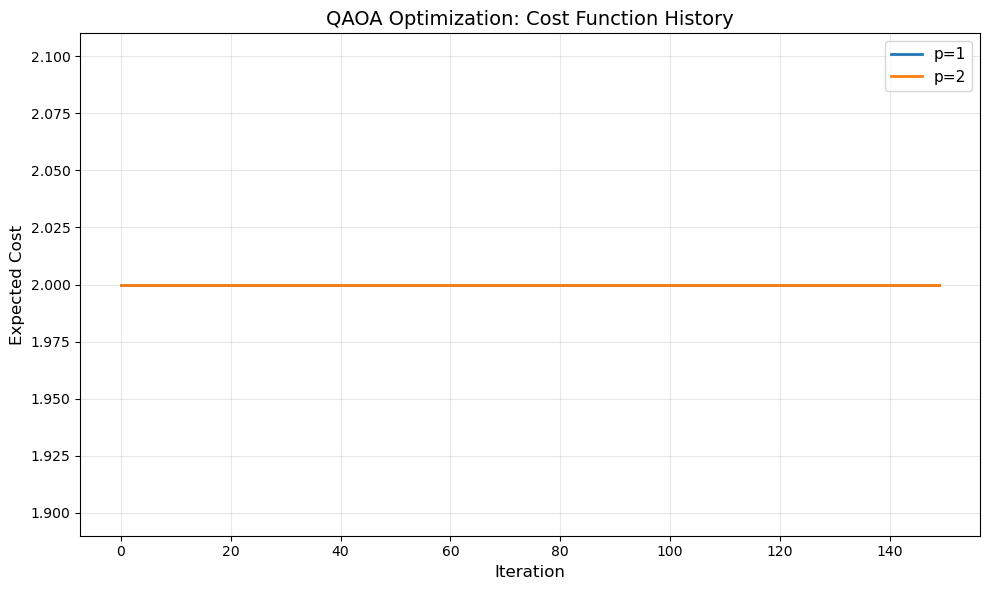

Cost histories plotted.


In [4]:
# Plot cost function history
fig, ax = plt.subplots(figsize=(10, 6))

for p_depth in [1, 2]:
    ax.plot(results_p[p_depth]['cost_history'], label=f'p={p_depth}', linewidth=2)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Expected Cost', fontsize=12)
ax.set_title('QAOA Optimization: Cost Function History', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cost histories plotted.")

In [5]:
# Sample from the final state and show top 5 bitstrings

def sample_qaoa(gamma, beta, p, dev, n_shots=1024):
    """Sample bitstrings from the QAOA circuit."""
    @qml.qnode(dev)
    def circuit():
        # Initial state
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        
        # p layers
        for layer in range(p):
            for i, j in edges:
                qml.IsingZZ(2 * gamma[layer], wires=[i, j])
            for i in range(n_qubits):
                qml.RX(2 * beta[layer], wires=i)
        
        return qml.probs(wires=range(n_qubits))
    
    probs = circuit()
    outcomes = np.random.choice(range(2**n_qubits), size=n_shots, p=probs)
    bitstrings = [format(o, f'0{n_qubits}b') for o in outcomes]
    return bitstrings

for p_depth in [1, 2]:
    print(f"\n{'='*50}")
    print(f"Top 5 bitstrings for p={p_depth}")
    print(f"{'='*50}")
    
    dev = qml.device('default.qubit', wires=n_qubits)
    gamma = results_p[p_depth]['params'][:p_depth]
    beta = results_p[p_depth]['params'][p_depth:2*p_depth]
    
    bitstrings = sample_qaoa(gamma, beta, p_depth, dev, n_shots=n_shots)
    
    # Count occurrences
    from collections import Counter
    counts = Counter(bitstrings)
    top_5 = counts.most_common(5)
    
    for idx, (bitstring, count) in enumerate(top_5, 1):
        cost = qaoa_cost_hamiltonian([int(b) for b in bitstring])
        prob = count / n_shots
        print(f"{idx}. {bitstring}: count={count}, prob={prob:.3f}, cost={cost}")


Top 5 bitstrings for p=1
1. 0000: count=253, prob=0.247, cost=0.0
2. 1111: count=234, prob=0.229, cost=0.0
3. 0110: count=62, prob=0.061, cost=2.0
4. 1010: count=56, prob=0.055, cost=4.0
5. 0101: count=55, prob=0.054, cost=4.0

Top 5 bitstrings for p=2
1. 1010: count=139, prob=0.136, cost=4.0
2. 1001: count=125, prob=0.122, cost=2.0
3. 0110: count=121, prob=0.118, cost=2.0
4. 0011: count=117, prob=0.114, cost=2.0
5. 0101: count=110, prob=0.107, cost=4.0


## Programming Task P12.2 (Solution)

**Quantum Circuit Born Machine**

Train a 4-qubit PQC to reproduce a discretized Gaussian distribution. Use KL divergence loss.

In [6]:
# Setup target distribution: Gaussian(mu=8, sigma=2) over [0, 15]
n_qubits_bm = 4
x_bins = np.arange(16)
target_dist = np.exp(-0.5 * ((x_bins - 8) / 2)**2)
target_dist /= target_dist.sum()  # Normalize

print("Target distribution (Gaussian):")
print(target_dist)

Target distribution (Gaussian):
[6.69207677e-05 4.36378221e-04 2.21611147e-03 8.76489088e-03
 2.69977646e-02 6.47642704e-02 1.20995586e-01 1.76047539e-01
 1.99487997e-01 1.76047539e-01 1.20995586e-01 6.47642704e-02
 2.69977646e-02 8.76489088e-03 2.21611147e-03 4.36378221e-04]


In [7]:
# Define the Quantum Born Machine with PennyLane

dev = qml.device('default.qubit', wires=n_qubits_bm)

@qml.qnode(dev)
def qbm_circuit(params):
    """4-qubit QBM with 2 layers of StronglyEntanglingLayers."""
    qml.StronglyEntanglingLayers(params, wires=range(n_qubits_bm))
    return qml.probs(wires=range(n_qubits_bm))

# Initialize parameters (2 layers, 4 qubits, 3 params per qubit per layer)
n_layers = 2
params_init = pnp.random.uniform(0, 2*np.pi, (n_layers, n_qubits_bm, 3), requires_grad=True)

print(f"Parameter shape: {params_init.shape}")
print(f"Total parameters: {params_init.size}")

Parameter shape: (2, 4, 3)
Total parameters: 24


In [8]:
# KL divergence loss

target_p = pnp.array(target_dist, requires_grad=False)

def kl_divergence_loss(params):
    """Compute KL divergence between target and learned distribution."""
    p_theta = qbm_circuit(params)
    
    # Avoid log(0)
    epsilon = 1e-10
    p_theta = pnp.clip(p_theta, epsilon, 1.0)
    target_clipped = pnp.clip(target_p, epsilon, 1.0)
    
    # KL(p* || p_theta) = sum p* log(p*/p_theta)
    kl = pnp.sum(target_clipped * pnp.log(target_clipped / p_theta))
    return kl

# Training with Adam optimizer
opt = AdamOptimizer(stepsize=0.05)
params = params_init
kl_history = []

print("Training Quantum Born Machine...")
for step in range(150):
    params, kl = opt.step_and_cost(kl_divergence_loss, params)
    kl_history.append(kl)
    
    if (step + 1) % 30 == 0:
        print(f"Step {step+1}: KL divergence = {kl:.6f}")

print(f"\nFinal KL divergence: {kl_history[-1]:.6f}")

Training Quantum Born Machine...


Step 30: KL divergence = 0.133655


Step 60: KL divergence = 0.036118


Step 90: KL divergence = 0.029939


Step 120: KL divergence = 0.026555


Step 150: KL divergence = 0.023434

Final KL divergence: 0.023434


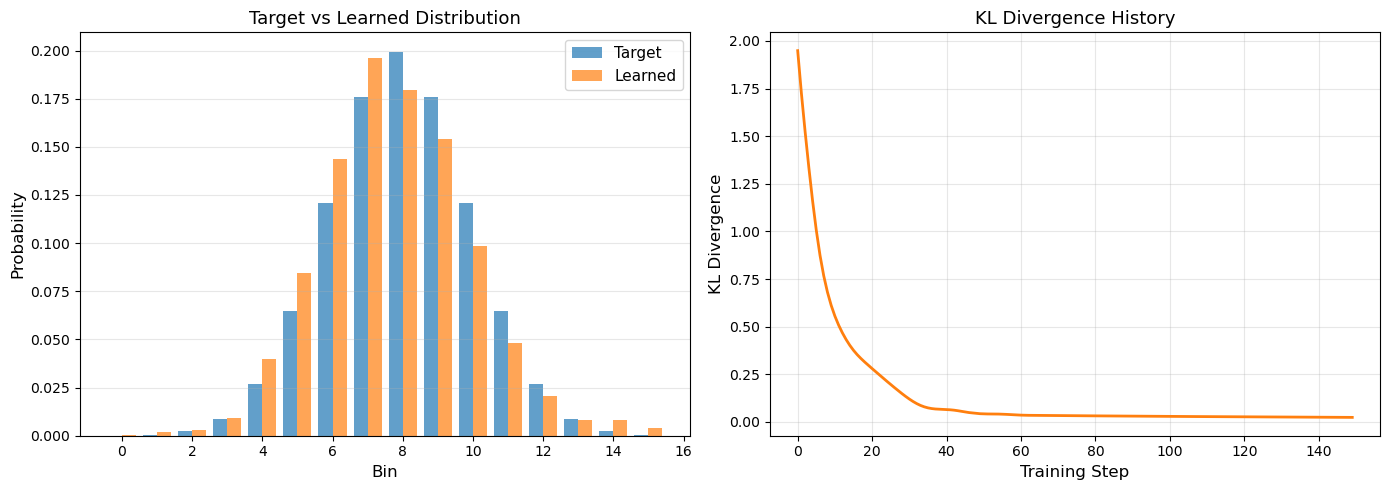


Distribution comparison plotted.


In [9]:
# Get learned distribution and plot
learned_dist = qbm_circuit(params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot distributions
ax1.bar(x_bins - 0.2, target_dist, width=0.4, label='Target', alpha=0.7)
ax1.bar(x_bins + 0.2, learned_dist, width=0.4, label='Learned', alpha=0.7)
ax1.set_xlabel('Bin', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Target vs Learned Distribution', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Plot KL divergence history
ax2.plot(kl_history, linewidth=2, color='tab:orange')
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('KL Divergence', fontsize=12)
ax2.set_title('KL Divergence History', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDistribution comparison plotted.")

## Programming Task P12.3 (Solution)

**QPINN for du/dx = -u with u(0) = 1**

Use a 1-qubit circuit with parameter-shift rule for spatial derivatives.

In [10]:
# Setup
n_qubits_qpinn = 1
n_collocation = 30
x_collocation = np.linspace(0, 3, n_collocation)
x_boundary = np.array([0.0])

dev_qpinn = qml.device('default.qubit', wires=n_qubits_qpinn)

@qml.qnode(dev_qpinn)
def qpinn_circuit(theta, x):
    """1-qubit circuit: Ry(theta1) Rz(pi*x) Ry(theta2)."""
    qml.RY(theta[0], wires=0)
    qml.RZ(np.pi * x, wires=0)
    qml.RY(theta[1], wires=0)
    return qml.expval(qml.Z(0))

def qpinn_loss(theta):
    """Combined PDE residual + boundary loss."""
    # PDE residual loss
    pde_loss = 0
    h = 1e-5  # Small step for numerical derivative
    
    for x in x_collocation:
        # Parameter-shift rule for du/dx
        u_plus = qpinn_circuit(theta, x + np.pi / 2)
        u_minus = qpinn_circuit(theta, x - np.pi / 2)
        dudx = (u_plus - u_minus) / 2
        
        u = qpinn_circuit(theta, x)
        
        # Residual: du/dx + u = 0
        residual = dudx + u
        pde_loss += residual ** 2
    
    pde_loss /= n_collocation
    
    # Boundary loss: u(0) = 1
    u_boundary = qpinn_circuit(theta, 0.0)
    boundary_loss = (u_boundary - 1.0) ** 2
    
    total_loss = pde_loss + boundary_loss
    return total_loss

# Initialize parameters
theta_init = pnp.array(np.random.uniform(0, 2*np.pi, 2), requires_grad=True)

# Adam optimizer
opt = AdamOptimizer(stepsize=0.08)
theta = theta_init
loss_history = []

print("Training QPINN...")
for step in range(200):
    theta, loss = opt.step_and_cost(qpinn_loss, theta)
    loss_history.append(loss)
    
    if (step + 1) % 40 == 0:
        print(f"Step {step+1}: loss = {loss:.6f}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

Training QPINN...


Step 40: loss = 0.372493


Step 80: loss = 0.372334


Step 120: loss = 0.372329


Step 160: loss = 0.372329


Step 200: loss = 0.372329

Final loss: 0.372329


In [11]:
# Evaluate learned solution and compare to analytical solution

x_test = np.linspace(0, 3, 100)
u_learned = np.array([qpinn_circuit(theta, x) for x in x_test])
u_analytical = np.exp(-x_test)  # Analytical solution: e^{-x}

# Compute max absolute error
max_error = np.max(np.abs(u_learned - u_analytical))
mse = np.mean((u_learned - u_analytical) ** 2)

print(f"Maximum absolute error: {max_error:.6f}")
print(f"Mean squared error: {mse:.6f}")

Maximum absolute error: 0.494933
Mean squared error: 0.095971


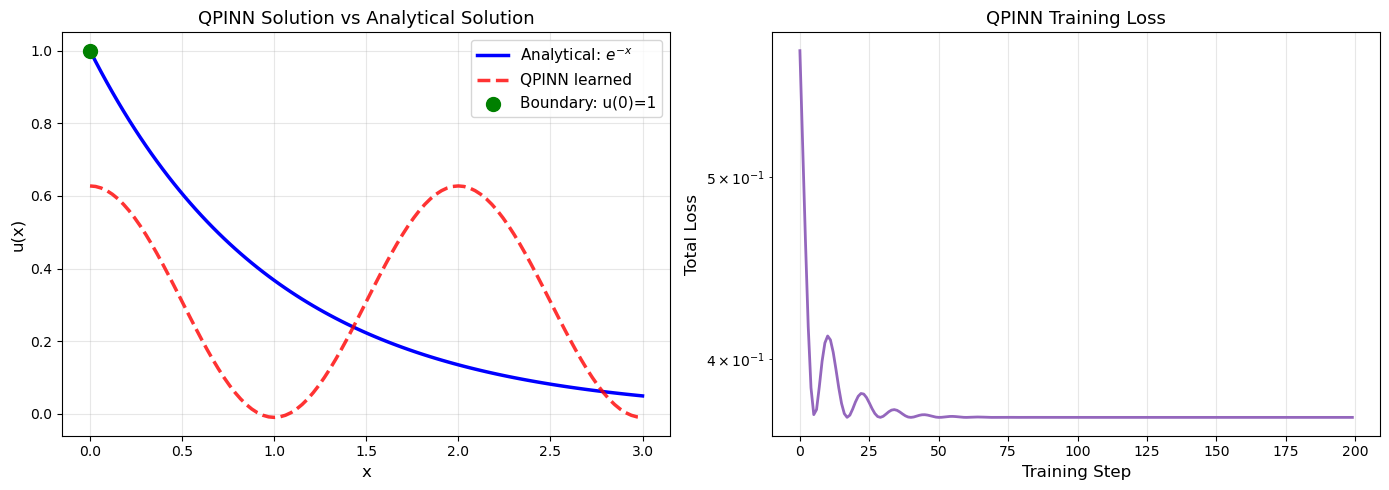

Solution plots displayed.


In [12]:
# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot solution
ax1.plot(x_test, u_analytical, 'b-', label=r'Analytical: $e^{-x}$', linewidth=2.5)
ax1.plot(x_test, u_learned, 'r--', label='QPINN learned', linewidth=2.5, alpha=0.8)
ax1.scatter([0], [1], color='green', s=100, marker='o', label='Boundary: u(0)=1', zorder=5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('u(x)', fontsize=12)
ax1.set_title('QPINN Solution vs Analytical Solution', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot loss history
ax2.plot(loss_history, linewidth=2, color='tab:purple')
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Total Loss', fontsize=12)
ax2.set_title('QPINN Training Loss', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("Solution plots displayed.")

## Summary

This notebook demonstrates three key advanced QML techniques:

1. **QAOA (Quantum Approximate Optimization Algorithm)**: Solves combinatorial optimization problems by iteratively applying cost and mixer Hamiltonians. Higher p values generally improve approximation ratios but require more circuit depth.

2. **Quantum Born Machines**: Use parameterized quantum circuits to learn probability distributions. The training objective is to minimize KL divergence between target and learned distributions.

3. **Quantum Physics-Informed Neural Networks (QPINNs)**: Embed physical constraints (PDEs) directly into the training loss. The parameter-shift rule enables efficient gradient-free computation of spatial derivatives.

All examples use PennyLane's native differentiation and optimization routines, demonstrating practical hybrid quantum-classical workflows.